In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
df=pd.read_csv('/content/traffic_light_controller_dataset.csv',encoding='unicode_escape')
df.shape

(1200, 9)

In [ ]:
df.head()

,record_id,intersection_id,timestamp,signal_state,vehicle_count,avg_vehicle_speed_kmph,queue_length,emergency_vehicle_detected,pedestrian_request
0,1,INT_04,2025-01-01 00:00:30,RED,1,1.08,8,1,0
1,2,INT_04,2025-01-01 00:01:00,RED,0,2.31,1,0,1
2,3,INT_02,2025-01-01 00:01:30,RED,3,3.59,23,0,1
3,4,INT_03,2025-01-01 00:02:00,RED,3,3.61,29,0,1
4,5,INT_02,2025-01-01 00:02:30,YELLOW,10,15.79,13,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   record_id                   1200 non-null   int64  
 1   intersection_id             1200 non-null   object 
 2   timestamp                   1200 non-null   object 
 3   signal_state                1200 non-null   object 
 4   vehicle_count               1200 non-null   int64  
 5   avg_vehicle_speed_kmph      1200 non-null   float64
 6   queue_length                1200 non-null   int64  
 7   emergency_vehicle_detected  1200 non-null   int64  
 8   pedestrian_request          1200 non-null   int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 84.5+ KB


In [ ]:
pd.isnull(df).sum()

,0
record_id,0
intersection_id,0
timestamp,0
signal_state,0
vehicle_count,0
avg_vehicle_speed_kmph,0
queue_length,0
emergency_vehicle_detected,0
pedestrian_request,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df['avg_vehicle_speed_kmph']=df['avg_vehicle_speed_kmph'].astype('int')

In [ ]:
df['avg_vehicle_speed_kmph'].dtypes

dtype('int64')

In [ ]:
df.columns

Index(['record_id', 'intersection_id', 'timestamp', 'signal_state',
       'vehicle_count', 'avg_vehicle_speed_kmph', 'queue_length',
       'emergency_vehicle_detected', 'pedestrian_request'],
      dtype='object')

In [ ]:
df.rename(columns={'avg_vehicle_speed_kmph':'avg_speed_kmph'})

,record_id,intersection_id,timestamp,signal_state,vehicle_count,avg_speed_kmph,queue_length,emergency_vehicle_detected,pedestrian_request
0,1,INT_04,2025-01-01 00:00:30,RED,1,1,8,1,0
1,2,INT_04,2025-01-01 00:01:00,RED,0,2,1,0,1
2,3,INT_02,2025-01-01 00:01:30,RED,3,3,23,0,1
3,4,INT_03,2025-01-01 00:02:00,RED,3,3,29,0,1
4,5,INT_02,2025-01-01 00:02:30,YELLOW,10,15,13,0,0
...,...,...,...,...,...,...,...,...,...
1195,1196,INT_04,2025-01-01 09:58:00,YELLOW,5,15,1,1,0
1196,1197,INT_04,2025-01-01 09:58:30,GREEN,10,55,16,0,1
1197,1198,INT_03,2025-01-01 09:59:00,RED,3,0,7,1,1
1198,1199,INT_04,2025-01-01 09:59:30,RED,2,0,1,0,0


In [ ]:
df.describe()

,record_id,vehicle_count,avg_vehicle_speed_kmph,queue_length,emergency_vehicle_detected,pedestrian_request
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,600.500000,11.605833,20.592500,14.756667,0.259167,0.489167
std,346.554469,11.402214,17.589275,8.871850,0.438360,0.500091
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,300.750000,3.000000,3.000000,7.000000,0.000000,0.000000
50%,600.500000,6.500000,17.000000,15.000000,0.000000,0.000000
75%,900.250000,18.000000,34.000000,22.000000,1.000000,1.000000
max,1200.000000,40.000000,59.000000,30.000000,1.000000,1.000000


In [ ]:
df[['intersection_id','signal_state']].describe()

,intersection_id,signal_state
count,1200,1200
unique,4,3
top,INT_01,GREEN
freq,307,415


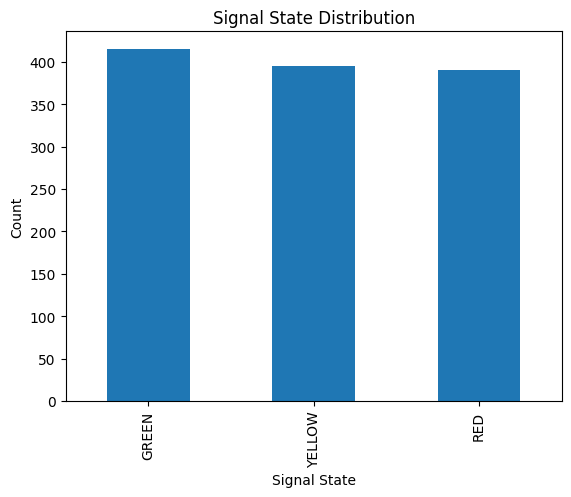

In [ ]:
df['signal_state'].value_counts().plot(kind='bar')
plt.title("Signal State Distribution")
plt.xlabel("Signal State")
plt.ylabel("Count")
plt.show()

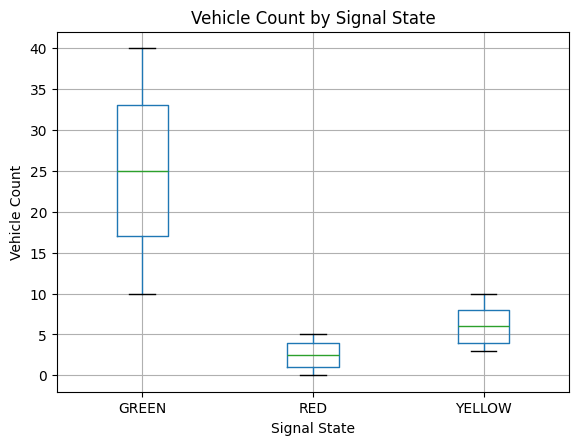

In [ ]:
df.boxplot(column='vehicle_count', by='signal_state')
plt.title("Vehicle Count by Signal State")
plt.suptitle("")
plt.xlabel("Signal State")
plt.ylabel("Vehicle Count")
plt.show()

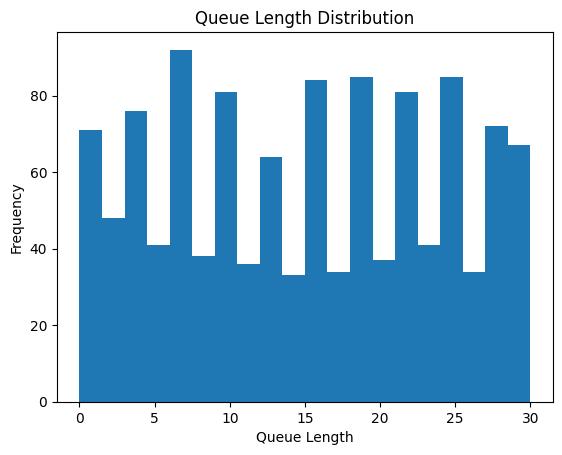

In [ ]:
plt.hist(df['queue_length'], bins=20)
plt.title("Queue Length Distribution")
plt.xlabel("Queue Length")
plt.ylabel("Frequency")
plt.show()

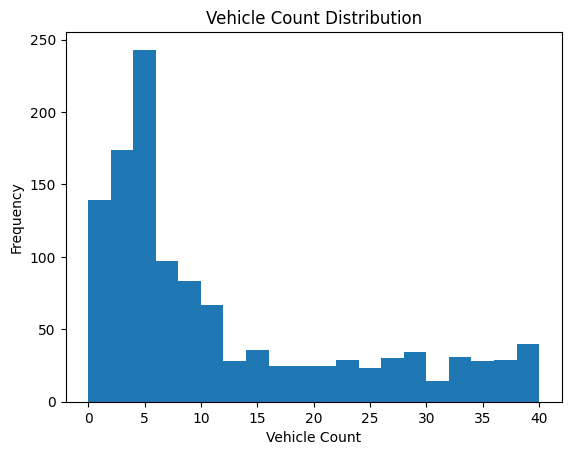

In [ ]:
plt.hist(df['vehicle_count'], bins=20)
plt.title("Vehicle Count Distribution")
plt.xlabel("Vehicle Count")
plt.ylabel("Frequency")
plt.show()

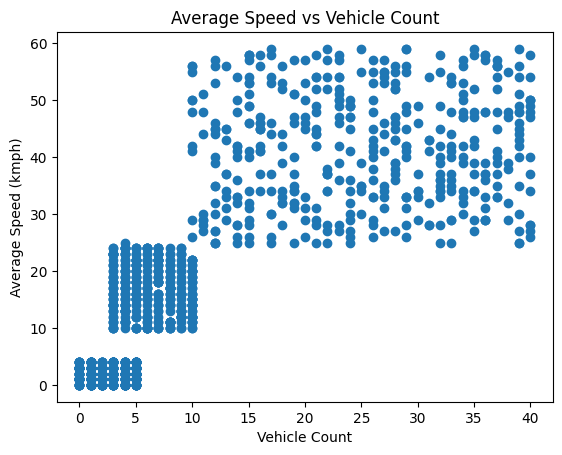

In [ ]:
plt.scatter(df['vehicle_count'], df['avg_vehicle_speed_kmph'])
plt.title("Average Speed vs Vehicle Count")
plt.xlabel("Vehicle Count")
plt.ylabel("Average Speed (kmph)")
plt.show()

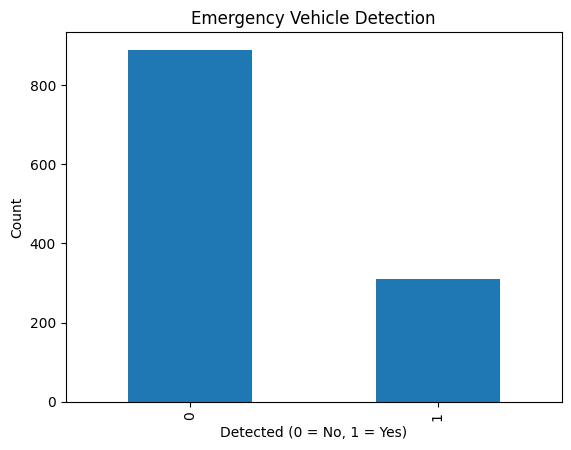

In [ ]:
df['emergency_vehicle_detected'].value_counts().plot(kind='bar')
plt.title("Emergency Vehicle Detection")
plt.xlabel("Detected (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

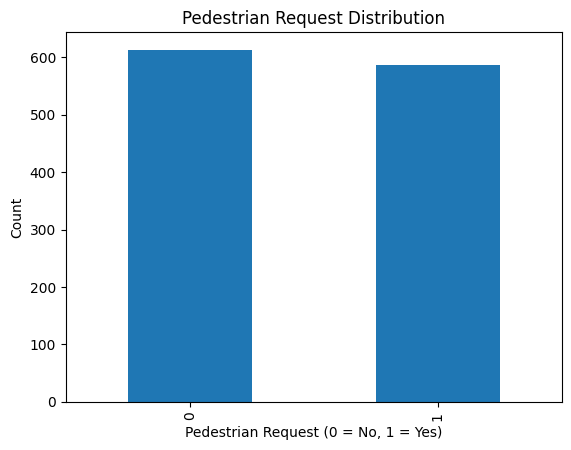

In [ ]:
df['pedestrian_request'].value_counts().plot(kind='bar')
plt.title("Pedestrian Request Distribution")
plt.xlabel("Pedestrian Request (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

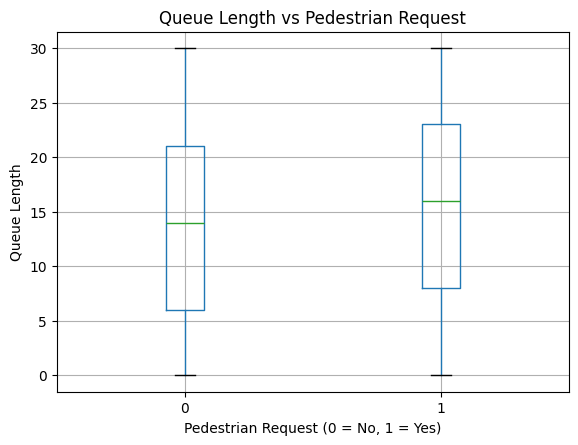

In [ ]:
df.boxplot(column='queue_length', by='pedestrian_request')
plt.title("Queue Length vs Pedestrian Request")
plt.suptitle("")
plt.xlabel("Pedestrian Request (0 = No, 1 = Yes)")
plt.ylabel("Queue Length")
plt.show()

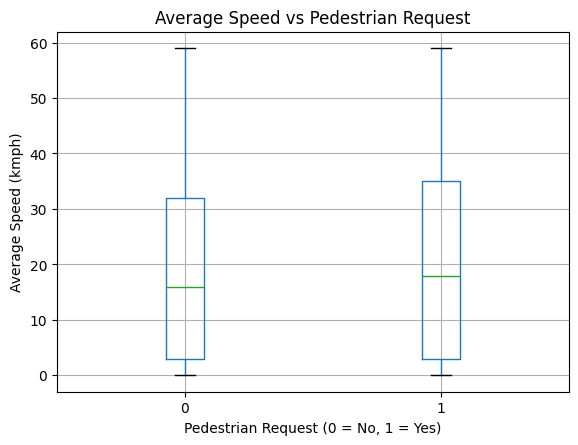

In [ ]:
df.boxplot(column='avg_vehicle_speed_kmph', by='pedestrian_request')
plt.title("Average Speed vs Pedestrian Request")
plt.suptitle("")
plt.xlabel("Pedestrian Request (0 = No, 1 = Yes)")
plt.ylabel("Average Speed (kmph)")
plt.show()

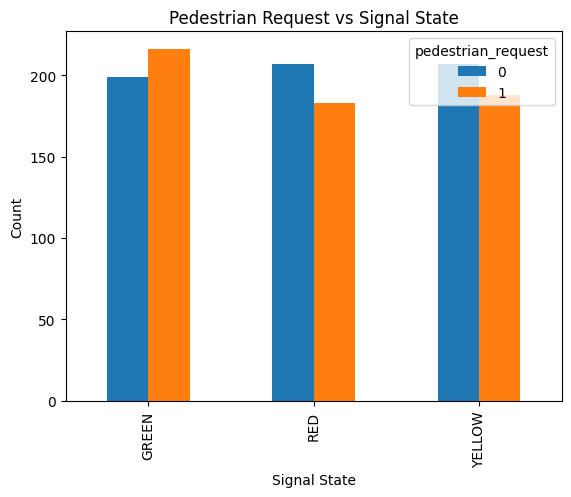

In [ ]:
pd.crosstab(df['signal_state'], df['pedestrian_request']).plot(kind='bar')
plt.title("Pedestrian Request vs Signal State")
plt.xlabel("Signal State")
plt.ylabel("Count")
plt.show()